In [1]:
import numpy as np
from qutip import *
from matplotlib import pyplot as plt

kB   = 1.380649e-23
hbar = 1.054571817e-34


In [2]:
from qutip import basis, mesolve, expect
from qutip import destroy
from dataclasses import dataclass
import numpy as np


@dataclass(slots=True)
class ThermalQutritParams:
    """
    Thermalized qutrit coupled to a bosonic bath
    satisfying detailed balance.
    """
    N: int = 3
    wq: float = 2 * np.pi * 5e9

    T1_down: float = 28e-6
    Temperature: float = 140.5e-3
    T_phi: float = 1.0e-6

    @property
    def P1_th(self):
        beta = hbar * self.wq / (kB * self.Temperature)
        return np.exp(-beta)

    @property
    def Gamma_down(self):
        return 1 / self.T1_down

    @property
    def Gamma_up(self):
        return self.Gamma_down * self.P1_th 

    @property
    def gamma_phi(self):
        return 1 / self.T_phi

    @property
    def T2(self):
        return 1 / (self.Gamma_down / 2 + self.Gamma_up / 2 + self.gamma_phi)


def build_thermal_qutrit(params: ThermalQutritParams):

    a = destroy(params.N)
    adag = a.dag()
    n = adag * a

    H = params.wq * n*0

    c_ops = [
        np.sqrt(params.Gamma_down) * a,
        np.sqrt(params.Gamma_up) * adag,
        # np.sqrt(params.gamma_phi) * n,
    ]

    return H, c_ops


def run_thermal_relaxation(
    params: ThermalQutritParams,
    psi0=None,
    ts=None,
):

    if psi0 is None:
        psi0 = basis(params.N, 1)

    if ts is None:
        ts = np.linspace(0, 175e-6, 1000)

    H, c_ops = build_thermal_qutrit(params)

    result = mesolve(H, psi0, ts, c_ops)

    # projectors
    P0 = basis(params.N, 0) * basis(params.N, 0).dag()
    P1 = basis(params.N, 1) * basis(params.N, 1).dag()
    P2 = basis(params.N, 2) * basis(params.N, 2).dag()

    P0_t = expect(P0, result.states)
    P1_t = expect(P1, result.states)
    P2_t = expect(P2, result.states)

    return ts, P0_t, P1_t, P2_t

T2 = 0.98 us


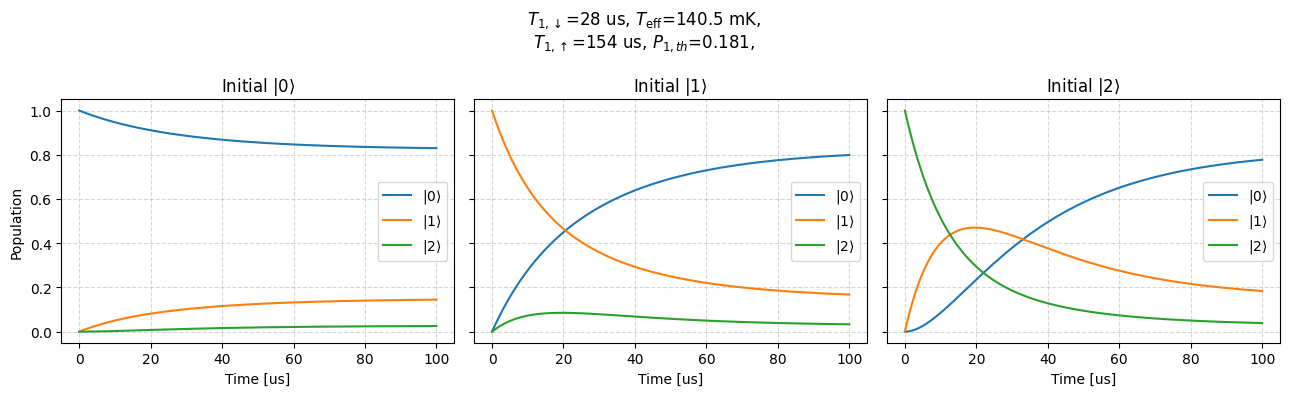

In [3]:
params = ThermalQutritParams()

print(f'T2 = {params.T2*1e6:.2f} us')

ts = np.linspace(0, 100e-6, 1000)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True,)

for ax, init_state, title in zip(
    axes,
    [basis(params.N, 0), basis(params.N, 1), basis(params.N, 2)],
    [r'Initial $|0\rangle$', r'Initial $|1\rangle$', r'Initial $|2\rangle$'],
):
    ts, P0, P1, P2 = run_thermal_relaxation(params, psi0=init_state, ts=ts)
    ax.plot(ts/1e-6, P0, label=r'$|0\rangle$')
    ax.plot(ts/1e-6, P1, label=r'$|1\rangle$')
    ax.plot(ts/1e-6, P2, label=r'$|2\rangle$')
    # ax.set_xlim(ts[0]/1e-6, ts[-1]/1e-6)
    # ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_xlabel('Time [us]')
    ax.grid(linestyle='--', alpha=0.5)
    # ax.set_ylim(0,0.01)
    ax.legend()

axes[0].set_ylabel('Population')
T1_up = 1 / params.Gamma_up
fig.suptitle(
    fr'$T_{{1,\downarrow}}$={params.T1_down/1e-6:.3g} us, '
    fr'$T_{{\text{{eff}}}}$={params.Temperature*1e3:.1f} mK, '
    '\n'
    # fr'$T_{{\phi}}$={params.T_phi:.3g} us, '
    fr'$T_{{1,\uparrow}}$={T1_up/1e-6:.3g} us, '
    fr'$P_{{1,th}}$={params.P1_th:.3g}, '
)

plt.tight_layout()
plt.savefig('three_states_T1.png', dpi=300)


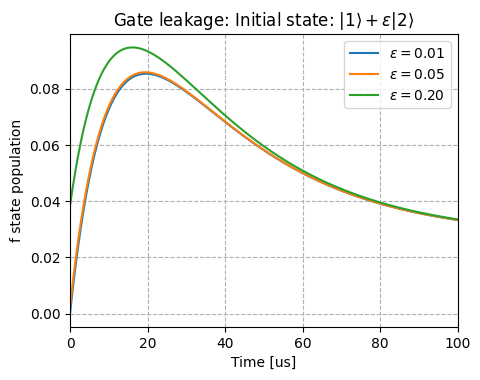

In [4]:
epsilons = [0.01, 0.05, 0.2]

fig, ax = plt.subplots(figsize=(5, 3.8))
for epsilon in epsilons:

    init_state = (basis(params.N, 1) + epsilon*basis(params.N, 2)).unit()
    ts, P0, P1, P2 = run_thermal_relaxation(params, psi0=init_state, ts=ts)
# ax.plot(ts, P0, label=r'$|0\rangle$')
# ax.plot(ts, P1, label=r'$|1\rangle$')
    ax.plot(ts/1e-6, P2, label=r'$\epsilon={:.2f}$'.format(epsilon))
ax.set_xlim(ts[0]/1e-6, ts[-1]/1e-6)
# ax.set_ylim(0, 0.2)
ax.set_ylabel('f state population')
ax.set_title(r'Gate leakage: Initial state: $|1\rangle + \epsilon|2\rangle$')
ax.set_xlabel('Time [us]')
ax.legend()
ax.grid(linestyle='--')

plt.savefig('three_states_T1_leakage.png', dpi=300)


In [5]:
def P_comp(N=3):
    P = basis(N,0)*basis(N,0).dag()*0
    P += basis(N,0)*basis(N,0).dag()
    P += basis(N,1)*basis(N,1).dag()
    # P += basis(N,2)*basis(N,2).dag()
    return P

def apply_super(S, rho):
    # S: superoperator, rho: operator
    return vector_to_operator(S * operator_to_vector(rho))




/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/core/data/expm.py:139: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


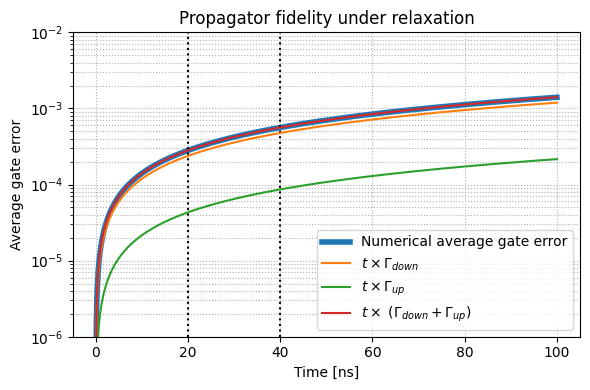

In [6]:
ts = np.linspace(0.00e-6, 0.1e-6, 1000)


# params.Temperature = 2e-3
H, c_ops = build_thermal_qutrit(params)
I = P_comp(params.N)
I = qeye(params.N)
idle_super = spre(I) * spost(I)
U_ts = [propagator(H, t, c_ops) for t in ts]
fidelity_t = np.array([process_fidelity(U, idle_super) for U in U_ts])
plt.figure(figsize=(6, 4))
plt.plot(ts/1e-9, (1-fidelity_t)/3, label='Numerical average gate error',linewidth=4)
plt.xlabel("Time [ns]")
plt.ylabel("Average gate error")
plt.yscale('log')
plt.ylim(1e-6, 1e-2)
plt.grid(True, which='both', ls=':')
plt.axvline(x=40, color='black', linestyle=':')
plt.axvline(x=20, color='black', linestyle=':')


# plt.plot(ts/1e-9,ts*(params.Gamma_down+params.Gamma_up), label='Analytic error bound')
plt.plot(ts/1e-9,ts*(params.Gamma_down)/3, label=r'$t\times\Gamma_{down}$')
plt.plot(ts/1e-9,ts*(params.Gamma_up)/3, label=r'$t\times\Gamma_{up}$')
plt.plot(ts/1e-9,ts*(params.Gamma_down+params.Gamma_up)/3,linestyle = '-', label=r'$t \times$ ($\Gamma_{down} + \Gamma_{up})$')


plt.title("Propagator fidelity under relaxation")
plt.legend()
plt.savefig('three_states_T1_fidelity.png', dpi=300)
plt.tight_layout()